In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/raw/HAM10000_metadata.csv")
df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  str    
 1   image_id      10015 non-null  str    
 2   dx            10015 non-null  str    
 3   dx_type       10015 non-null  str    
 4   age           9958 non-null   float64
 5   sex           10015 non-null  str    
 6   localization  10015 non-null  str    
dtypes: float64(1), str(6)
memory usage: 547.8 KB


In [4]:
df["dx"].value_counts()

dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

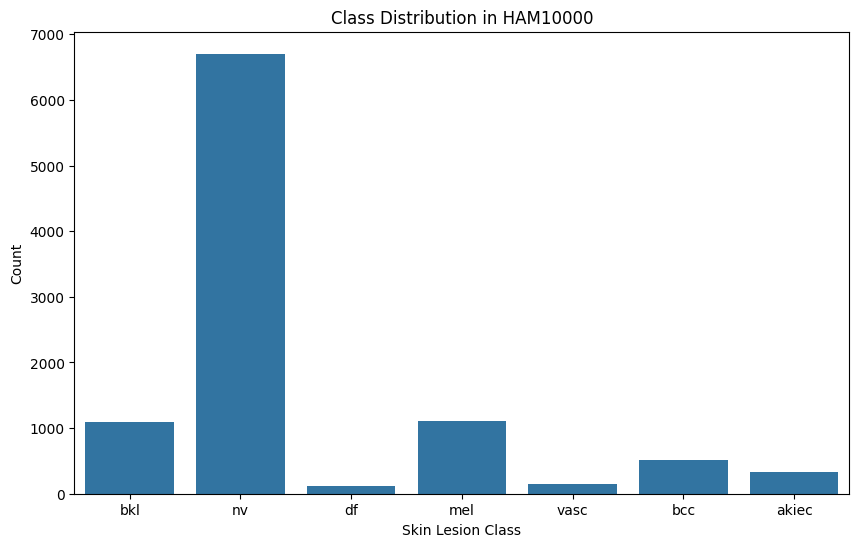

In [5]:
plt.figure(figsize=(10,6))
sns.countplot(x="dx", data=df)
plt.title("Class Distribution in HAM10000")
plt.xlabel("Skin Lesion Class")
plt.ylabel("Count")
plt.show()

In [6]:
plt.savefig("../outputs/figures/class_distribution.png")


<Figure size 640x480 with 0 Axes>

In [7]:
# Lesion Image Visualization

In [8]:
from PIL import Image
import os

In [9]:
image_dir_1 = "../data/raw/HAM10000_images_part_1"
image_dir_2 = "../data/raw/HAM10000_images_part_2"

image_paths = {}

for folder in [image_dir_1, image_dir_2]:
    for img in os.listdir(folder):
        image_id = img.split(".")[0]
        image_paths[image_id] = os.path.join(folder, img)
        

In [10]:
df["image_path"] = df["image_id"].map(image_paths)

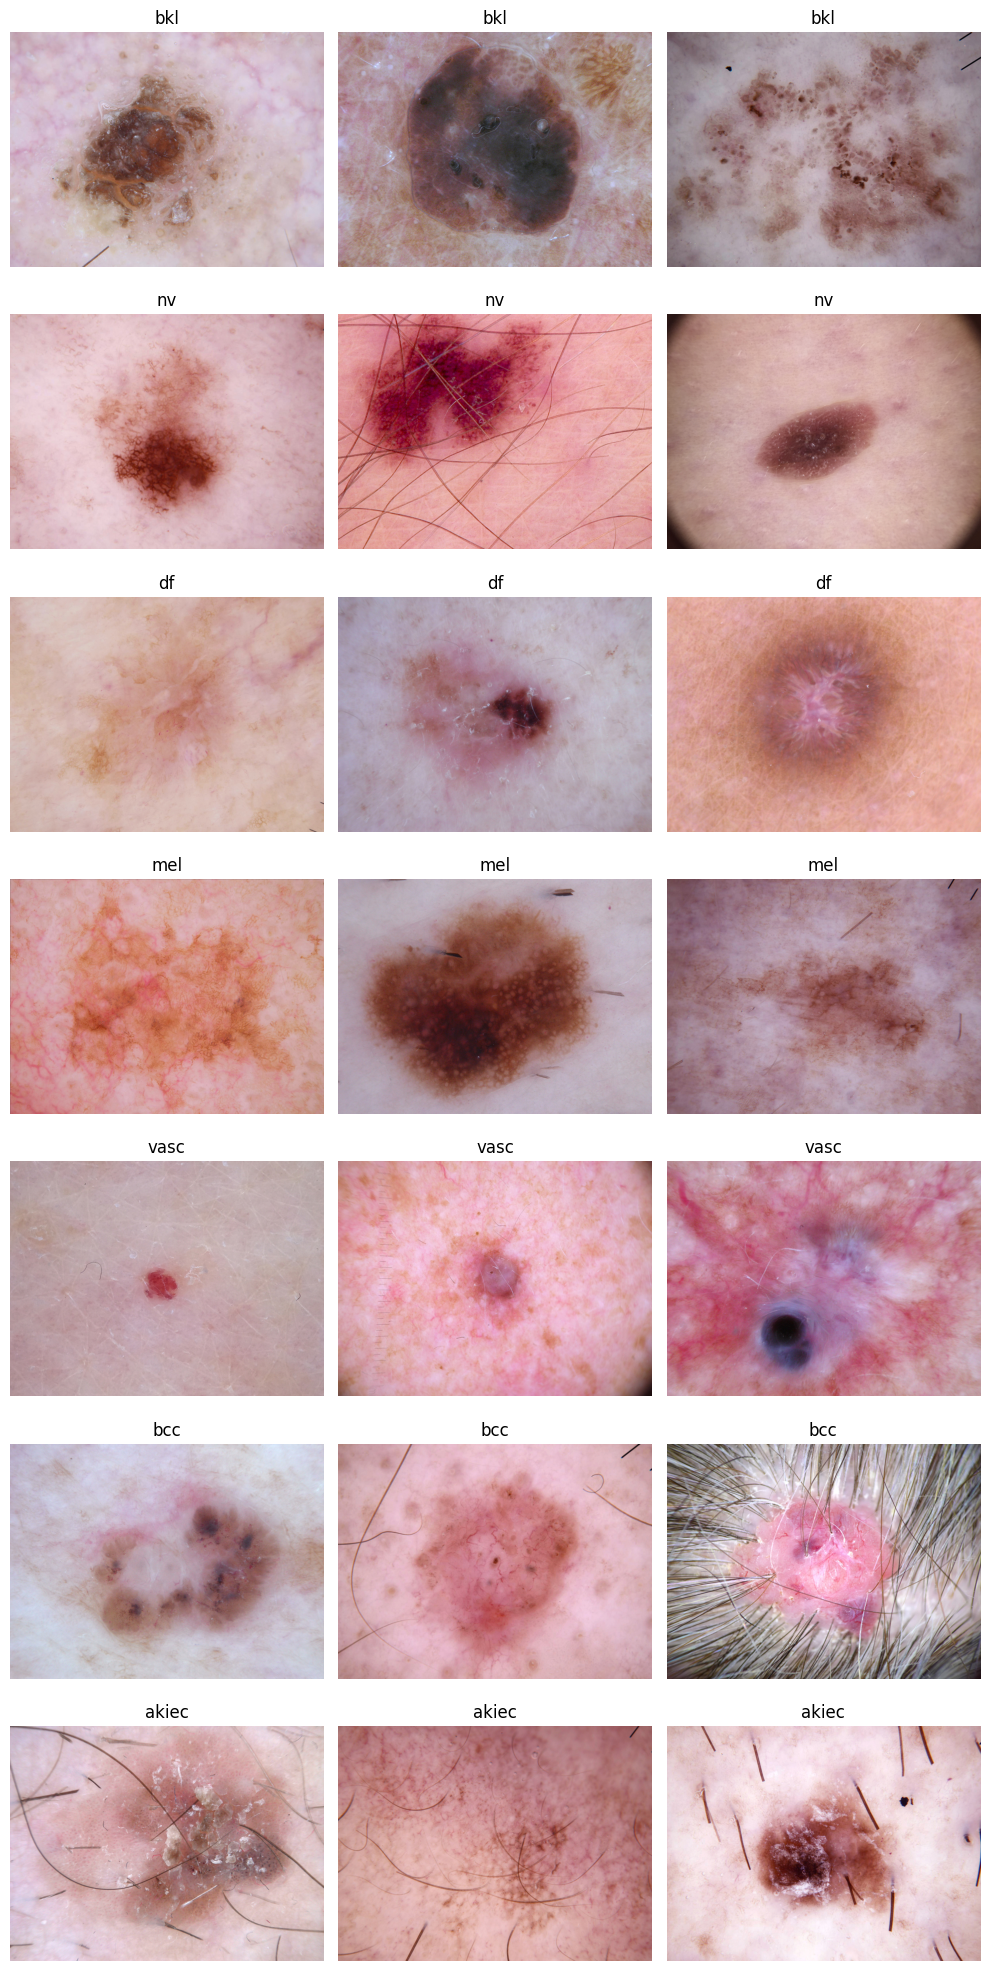

In [11]:
classes = df["dx"].unique()

fig, axes = plt.subplots(len(classes), 3, figsize=(10, 20))

for i, lesion_class in enumerate(classes):
    samples = df[df["dx"] == lesion_class].sample(3)

    for j, (_, row) in enumerate(samples.iterrows()):
        img = Image.open(row["image_path"])

        axes[i, j].imshow(img)
        axes[i, j].set_title(lesion_class)
        axes[i, j].axis("off")

plt.tight_layout()
plt.show()